<a href="https://colab.research.google.com/github/ab1d52/Secrets/blob/master/First_ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Downgrading Python to 3.9

To downgrade Python in Google Colab, we need to install Python 3.9 and then configure the system to use it as the default Python interpreter. After running the following cells, you will need to restart the Colab runtime for the changes to take effect.

In [3]:
# Install Python 3.9
!sudo apt-get update -y
!sudo apt-get install python3.9 -y

# Update alternatives to set Python 3.9 as default
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.9 1

print('Python 3.9 installed and set as default. Please restart your Colab runtime.')

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,129 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,973 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,299 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,040 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Ge

In [3]:
# Verify the Python version after restarting the runtime
!python3 --version

Python 3.12.13


## **Importing Libraries**

In [4]:
%%capture
!pip install mordred
!pip install rdkit


In [17]:
# Importing Libraries
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, PandasTools, AllChem, Descriptors

import mordred
from mordred import Calculator, descriptors

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

pd.set_option('display.max_columns', 2000)
warnings.filterwarnings("ignore")

In [ ]:
sns.set(style='whitegrid')

## **Generating Descriptors from SMILES - Mordred**

Youtube videos for generating molecular descriptors from SMILES

> https://youtu.be/EeOCGvy2pmQ


> https://youtu.be/Sgh-qJVYI5Q





In [7]:
data = pd.read_csv('polyinfo_sigma_csv.csv')
data.head()

,polymer_name,polymer_id,cu_formula,SMILES,Electric_conductivity(1/ohm*cm),log_sigma
0,"2,2'-dimethylbisphenol A polycarbonate",P150022,C18H18O3,*Oc1ccc(cc1C)C(c1ccc(c(c1)C)OC(=O)*)(C)C,2.700000e-17,-16.568636
1,"2,5-poly-1,6-di(N-carbazolyl)-2,4-hexadiyne",P210031,C30H20N2,*=C=C=C(C(=*)Cn1c2ccccc2c2c1cccc2)Cn1c2ccccc2c...,1.000000e-15,-15.000000
2,"2,5-poly-2,4-hexadiynediol-1,6-bis(p-toluylsul...",P210035,C20H18O6S2,*=C=C=C(C(=*)COS(=O)(=O)c1ccc(cc1)C)COS(=O)(=O...,7.010000e-12,-11.154282
3,"2,6-poly[4H-cyclopenta[2,1-b:3,4-b']dithiophen...",P382133,C12H2N2S2,N#CC(=C1c2cc(sc2-c2c1cc(s2)*)*)C#N,3.025000e-01,-0.519275
4,"3-[(2-oxo-1,3-dioxolan-4-yl)methoxy]prop-1-ene...",P472029,C8H14O5Si,*O[Si](CCCOCC1COC(=O)O1)(C)*,5.200000e-10,-9.283997


In [9]:
mol_list = []

for smile in data['SMILES']:
  mol = Chem.MolFromSmiles(smile)
  mol = Chem.AddHs(mol)
#   AllChem.EmbedMolecule(mol)
  mol_list.append(mol)

data = pd.concat([data, pd.DataFrame(mol_list, columns = (['Mol']))], axis=1)

In [10]:
data.head()

,polymer_name,polymer_id,cu_formula,SMILES,Electric_conductivity(1/ohm*cm),log_sigma,Mol
0,"2,2'-dimethylbisphenol A polycarbonate",P150022,C18H18O3,*Oc1ccc(cc1C)C(c1ccc(c(c1)C)OC(=O)*)(C)C,2.700000e-17,-16.568636,<rdkit.Chem.rdchem.Mol object at 0x7cf92750aea0>
1,"2,5-poly-1,6-di(N-carbazolyl)-2,4-hexadiyne",P210031,C30H20N2,*=C=C=C(C(=*)Cn1c2ccccc2c2c1cccc2)Cn1c2ccccc2c...,1.000000e-15,-15.000000,<rdkit.Chem.rdchem.Mol object at 0x7cf92750a420>
2,"2,5-poly-2,4-hexadiynediol-1,6-bis(p-toluylsul...",P210035,C20H18O6S2,*=C=C=C(C(=*)COS(=O)(=O)c1ccc(cc1)C)COS(=O)(=O...,7.010000e-12,-11.154282,<rdkit.Chem.rdchem.Mol object at 0x7cf92750a180>
3,"2,6-poly[4H-cyclopenta[2,1-b:3,4-b']dithiophen...",P382133,C12H2N2S2,N#CC(=C1c2cc(sc2-c2c1cc(s2)*)*)C#N,3.025000e-01,-0.519275,<rdkit.Chem.rdchem.Mol object at 0x7cf927509b60>
4,"3-[(2-oxo-1,3-dioxolan-4-yl)methoxy]prop-1-ene...",P472029,C8H14O5Si,*O[Si](CCCOCC1COC(=O)O1)(C)*,5.200000e-10,-9.283997,<rdkit.Chem.rdchem.Mol object at 0x7cf927363760>


In [13]:
mol = data['Mol'][59]

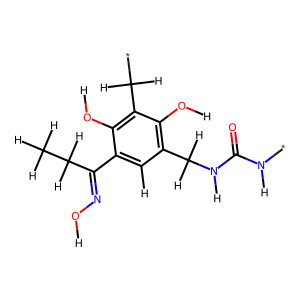

In [14]:
img = Draw.MolToImage(mol)
img

# Molecular Descriptors


In [15]:
from rdkit.ML.Descriptors import MoleculeDescriptors

In [18]:
Desc_list_func = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors.descList])

In [20]:

names = Desc_list_func.GetDescriptorNames()

names

('MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'SMR_VSA6',


In [21]:
print('Number of descriptors:', len(names))

Number of descriptors: 217


In [23]:
Des_func = MoleculeDescriptors.MolecularDescriptorCalculator(x[0] for x in Descriptors._descList)

In [24]:
des = []
for mol in data['Mol']:
  des.append(Des_func.CalcDescriptors(mol))

In [25]:

moldesc_df = pd.concat([data, pd.DataFrame(des, columns=(x[0] for x in Descriptors._descList))], axis=1)

In [28]:
moldesc_df.to_excel('log_sigma_2D.xlsx', index=None)

## **Loading the Dataset**

In [29]:
df = pd.read_excel('log_sigma_2D.xlsx')

## **Data Preprocessing**



1.   Removing missing values/non-numerical values
2.   Remove constant values
3.   Remove highly correlated values





In [30]:
df.head()

,polymer_name,polymer_id,cu_formula,SMILES,Electric_conductivity(1/ohm*cm),log_sigma,Mol,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAmideBonds,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumAtomStereoCenters,NumBridgeheadAtoms,NumHAcceptors,NumHDonors,NumHeteroatoms,NumHeterocycles,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumSpiroAtoms,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,"2,2'-dimethylbisphenol A polycarbonate",P150022,C18H18O3,*Oc1ccc(cc1C)C(c1ccc(c(c1)C)OC(=O)*)(C)C,2.700000e-17,-16.568636,<rdkit.Chem.rdchem.Mol object at 0x7cf92750aea0>,11.796611,11.796611,0.742597,-3.982058,0.826664,27.238095,282.339,264.195,282.125594,108,0,NaN,NaN,NaN,NaN,1.190476,1.809524,2.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.741172,3.570818,1376.621317,32.419767,28.224745,10.224745,18.205354,14.316497,5.316497,3.843644,3.843644,2.449915,2.449915,1.407775,1.407775,-2.290000,1.019926e+08,3.721441,4.621792,2.512410,150.036920,0.0,0.0,0.0,0.0,0.0,148.613703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.311582,6.472221,0.000000,0.000000,0.0,32.822559,0.000000,58.508318,0,11.499024,9.843390,4.794537,11.499024,0.000000,6.472221,5.414990,13.703784,60.631244,36.254512,0.000000,0.000000,0,35.53,109.302122,4.794537,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,34.517044,151.236101,0.000000,11.796611,5.152222,-9.062751,-1.813019,-7.773832,0.000000,-15.618666,0.000000,0.277778,21,0,3,0,0,0,0,2,0,2,0,0,3,0,5,0,4,0,0,0,0,0,0.819035,2,4.52054,81.1380,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,"2,5-poly-1,6-di(N-carbazolyl)-2,4-hexadiyne",P210031,C30H20N2,*=C=C

In [ ]:
data = df.iloc[:,3:]

In [ ]:
data.head()

In [ ]:
data.isnull().sum().sum()

In [ ]:
column_num = []
column_bool = []
for column in data.columns:
  column_type = data[column].dtype
  if column_type == 'object':
      pass
  elif column_type =='bool':
      column_bool.append(column)
  else:
      column_num.append(column)

In [ ]:
len(column_num)

In [ ]:
column_bool

In [ ]:
data['GhoseFilter'].unique()

In [ ]:
gf = data['GhoseFilter'].astype(int)
gf.value_counts().plot(kind='bar')


In [ ]:
data = data[column_num + column_bool]

In [ ]:
data.shape

In [ ]:
def remove_constant_values(data):
    return [e for e in data.columns if data[e].nunique() == 1]

drop_col = remove_constant_values(data)
#drop_col

new_df_columns = [e for e in data.columns if e not in drop_col]
new_df = data[new_df_columns]
new_df

In [ ]:
len(drop_col)

In [ ]:

# To calclulate  Correlation and remove highly  correlated columns
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [ ]:
# Dropping highly correlated Features
corr_features = correlation(new_df, 0.80)
print("No. of features to drop : ",len(set(corr_features)))

new_df.drop(corr_features,axis=1,inplace=True)

In [ ]:
new_df.shape

In [ ]:
new_df.head()

In [ ]:
new_df['Lipinski'] = df["Lipinski"].astype(int)
new_df['GhoseFilter'] = df["GhoseFilter"].astype(int)

In [ ]:
new_df.head()

In [ ]:
df_final = pd.concat([df.iloc[:, :3], new_df], axis=1)
df_final.head()

In [ ]:
df_final.shape

In [ ]:
df_final.to_csv('delaney_mordred_truncated.csv', index=None)

## **Data Analysis**

In [ ]:
df_final['measured log(solubility:mol/L)'].describe()

In [ ]:
plt.hist(df_final['measured log(solubility:mol/L)'])

In [ ]:
df_final = df_final.iloc[:, 2:]

In [ ]:
corr = df_final.corr()
corr

In [ ]:
corr_sorted = abs(corr[['measured log(solubility:mol/L)']]).sort_values(by ='measured log(solubility:mol/L)', ascending=False)
corr_sorted = corr_sorted.iloc[1:5, :]
corr_sorted.rename(columns={'measured log(solubility:mol/L)' : 'correlation_coef'}, inplace=True)
corr_sorted

In [ ]:
fig = plt.figure(1, figsize=(6,6))
ax1 = fig.add_subplot(111)
plt.bar(x = corr_sorted.index, height = corr_sorted['correlation_coef'], color = 'green')
ax1.set_xlabel('Top Correlated Descriptors', weight='bold')
ax1.set_ylabel('Correlation Coefficient', weight='bold')

In [ ]:
fig = plt.figure(4, figsize=(10,10))
ax = fig.add_subplot(221)
plt.scatter(x = df_final['measured log(solubility:mol/L)'], y = df_final['FilterItLogS'], color = 'green')
ax.set_xlabel('Log Solubilities', weight='bold')
ax.set_ylabel('FilterItLogS', weight='bold')

ax = fig.add_subplot(222)
plt.scatter(x = df_final['measured log(solubility:mol/L)'], y = df_final['PEOE_VSA6'], color = 'green')
ax.set_xlabel('Log Solubilities', weight='bold')
ax.set_ylabel('PEOE_VSA6', weight='bold')

ax = fig.add_subplot(223)
plt.scatter(x = df_final['measured log(solubility:mol/L)'], y = df_final['RNCG'], color = 'green')
ax.set_xlabel('Log Solubilities', weight='bold')
ax.set_ylabel('RNCG', weight='bold')

ax = fig.add_subplot(224)
plt.scatter(x = df_final['measured log(solubility:mol/L)'], y = df_final['ABC'], color = 'green')
ax.set_xlabel('Log Solubilities', weight='bold')
ax.set_ylabel('ABC', weight='bold')
plt.tight_layout()

In [ ]:
df_final = pd.read_csv('delaney_mordred_truncated.csv')

## **Building Machine Learning Model**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df_final = pd.read_csv('delaney_mordred_truncated.csv')

In [ ]:
df_final.head()

In [ ]:
df_final.shape

In [ ]:
y = df_final['measured log(solubility:mol/L)']

In [ ]:
scaled_DF = pd.DataFrame(StandardScaler().fit_transform(df_final.iloc[:,3:]), columns=([df_final.iloc[:,3:]]))


In [ ]:
scaled_DF

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(scaled_DF, y, test_size=0.20, random_state=45)

In [ ]:
X_test.shape

In [ ]:
# multiple linear regression model using statsmodels
x = sm.add_constant(X_train)
results = sm.OLS(y_train, x).fit()
print(results.summary())

In [ ]:
# multiple linear regression model using scikitlearn
lr = LinearRegression()
lr.fit(X_train, y_train)

In [ ]:
print(f'The r2 score for train set is : {lr.score(X_train, y_train)}')
print(f'The r2 score for test set is : {lr.score(X_test, y_test)}')

In [ ]:
y_hat_train = lr.predict(X_train)
y_hat_test = lr.predict(X_test)

In [ ]:
r2_score(y_train, y_hat_train)

In [ ]:
r2_score(y_test, y_hat_test)

In [ ]:
y_hat_train.shape

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

In [ ]:
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')

## **Cross-Validation**

In [ ]:
val = cross_val_score(rf, X_train, y_train,  scoring='r2', cv=5)

In [ ]:
val.mean()

## **Visualizing the Results**

In [ ]:
plt.scatter(y_test, rf.predict(X_test), label='Test')
sns.regplot(x = y_train, y = rf.predict(X_train), color = 'maroon',scatter_kws={'alpha':0.3}, label='Train' )
plt.xlabel('Measured Solubilities')
plt.ylabel('Predicted Solubilites')
plt.legend();

## **Screen Models using Lazypredict**

In [ ]:
%%capture
!pip install lazypredict

In [ ]:
from lazypredict.Supervised import LazyRegressor

In [ ]:
reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(predictions)

## **Dimensionality Reduction Techniques**

# **Principal Component Analysis**

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
scaled_DF.head()

In [ ]:
scaled_DF.shape


In [ ]:
pca = PCA(n_components=8)
pc = pca.fit_transform(scaled_DF)
pc_df = pd.DataFrame(data = pc)

In [ ]:
pc_df.head()

In [ ]:
pca.explained_variance_ratio_

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(pc_df, y, test_size=0.20, random_state=45)

In [ ]:
x = sm.add_constant(X_train)
results = sm.OLS(y_train, x).fit()
print(results.summary())

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f'The r2 score for train set is : {lr.score(X_train, y_train)}')
print(f'The r2 score for test set is : {lr.score(X_test, y_test)}')

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')

# **t-SNE**

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(n_components=2)
ts = tsne.fit_transform(scaled_DF)
tsne_df = pd.DataFrame(data = ts)


In [ ]:
tsne_df.head()

**Visuaization in Lower Dimensions**

In [ ]:
y.median()

In [ ]:
sol_cls = [int(boolean) for boolean in list(map(lambda s: s>-2.8, y))]

In [ ]:
from collections import Counter
Counter(sol_cls)

In [ ]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(tsne_df.iloc[:,0],tsne_df.iloc[:,1],
                      c = sol_cls,cmap='plasma'
                      )
plt.legend(handles=scatter.legend_elements()[0], labels=['More Soluble', 'Less Soluble'], loc = 1)
plt.xlabel('tsne Component 1')
plt.ylabel('tsne Component 2')